# Notebook 06 -- Machine Learning Models (Random Forest & XGBoost)

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-04

---

### Purpose

This notebook implements and evaluates **tree-based machine learning models** (Random Forest and XGBoost) as the next step in the progressive modelling strategy. These models relax the linearity assumption of SARIMAX (Notebook 05) and can capture non-linear interactions between exogenous variables and the target.

An initial implementation of this notebook revealed a critical issue: when the full feature set was used, the feature importance rankings were dominated by three near-collinear variables (contemporaneous `seats`, `nights_lag1`, `nights_lag12`), jointly accounting for 97% of the Random Forest importance. The macroeconomic variables received essentially zero weight. The collinearity diagnostic added to Notebook 04 (Section 6.2) confirmed that:

- `nights` vs `seats` : r = 0.877 (bidirectionally Granger-causal, Notebook 03).
- `nights` vs `nights_lag1` : r = 0.877 (trivial autoregressive dependency).
- `seats` vs `nights_lag1` : r = 0.815 (the two "best" features carry overlapping information).

The headline MAPE of the naive specification was therefore cosmetic: the model was exploiting near-tautological features rather than learning anything from the exogenous variables. This also has implications for the Notebook 08 pipeline (IMF scenario forecasting), where contemporaneous `seats` will not be available and the model must rely on macroeconomic predictors alone.


### Strategy

This notebook compares **four model specifications** of increasing restrictiveness, applied identically to both Random Forest and XGBoost. The progression isolates the marginal effect of each restriction:

1. **M1 -- Full**: all 14 features (baseline, retains all collinearity and endogenous shortcuts).
2. **M2 -- Curated**: M1 minus the three collinearity redundancies (`gdp_pc_DE`, `cci_DE` contemporaneous, `relprice_wavg`) AND minus contemporaneous `seats` (bidirectional Granger causality with `nights`, p < 0.001 in NB03). Keeps the autoregressive lags. M1 → M2 measures the cost of removing the cleanly endogenous variable plus redundancies.
3. **M3 -- NoLag1**: M2 minus `nights_lag1`. Retains `nights_lag12` and `seats_lag6`. M2 → M3 measures the cost of removing the short-run autoregressive shortcut, isolating the gap between an academic specification (Song et al. 2010 style, where lag1 is standard) and an operationally honest one (information lagged by 6+ months, the relevant horizon for industry deployment). *This is the architecture used in Notebook 08.*
4. **M4 -- Macro-only**: M3 minus `nights_lag12` and `seats_lag6`. Only macroeconomic variables and seasonal/COVID controls. Stress test. Not a standard specification in tourism demand modelling; included as a diagnostic for the predictive content of macro variables in isolation.

Each specification is evaluated using:

- **Single hold-out** (last 12 months) -- for direct comparability with Notebook 05.
- **Rolling-origin expanding-window backtest** at horizons h ∈ {1, 3, 6, 12} -- the standard in the tourism forecasting literature (Athanasopoulos et al. 2011; Song et al. 2019).
- **Diebold-Mariano tests** between specifications.

The central narrative: this comparison disentangles *informational content* (M2 vs M3 captures the value of `nights_lag1` for forecasting accuracy) from *operational availability* (M3 mirrors the constraints of a real-world deployment scenario where lagged target values are not yet observed). The same model can be the best choice for academic inference and the wrong choice for industry application — the four-way comparison makes this trade-off explicit.

## 0. Environment & Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
from itertools import product

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'font.size': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight', 'savefig.dpi': 200, 'savefig.facecolor': 'white',
})

COLORS = {
    'primary': '#2c3e50', 'secondary': '#e74c3c',
    'accent1': '#3498db', 'accent2': '#2ecc71',
    'accent3': '#f39c12', 'accent4': '#9b59b6', 'gray': '#95a5a6',
}
SPEC_COLORS = {
    'M1-Full':       COLORS['accent1'],
    'M2-Curated':    COLORS['accent2'],
    'M3-NoLag1':    COLORS['accent3'],
    'M4-MacroOnly':  COLORS['accent4'],
}

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIG_DIR        = os.path.join('..', 'figures', 'models')
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')

print('Environment ready.')

Environment ready.


---

## 1. Load Master Panel & Define the Four Specifications

In [2]:
panel = pd.read_csv(
    os.path.join(DATA_PROCESSED, 'master_panel_monthly.csv'),
    index_col=0, parse_dates=True
)
panel.index.name = 'date'
print(f'Panel: {panel.shape[0]} rows x {panel.shape[1]} cols')
print(f'Period: {panel.index[0]:%Y-%m} -> {panel.index[-1]:%Y-%m}')

TARGET = 'nights'
SEASONAL_DUMMIES = [f'month_{m:02d}' for m in range(1, 13)]
COVID_DUMMIES    = ['covid_strong', 'covid_post']

Panel: 179 rows x 39 cols
Period: 2011-01 -> 2025-11


In [3]:
# --- FOUR MODEL SPECIFICATIONS (revised per tutor feedback) ---
# The four specifications follow a sequential restriction logic, allowing
# the marginal effect of each restriction to be isolated:
#   M1 -> M2: drop redundancies + the contemporaneous endogenous variable (seats)
#   M2 -> M3: drop the short-run autoregressive shortcut (nights_lag1)
#   M3 -> M4: drop all remaining serial features (nights_lag12, seats_lag6)
# Seasonal dummies and 'trend' are added uniformly (orthogonal controls).

SPECS = {
    # M1 -- Full: the original naive feature set.
    # Retains all features including the near-tautological ones.
    'M1-Full': [
        'hicp_ratio', 'relprice_wavg', 'exr_pln',
        'gdp_pc_origins_wavg', 'pop_origins_wavg', 'gdp_pc_DE',
        'cci_DE',
        'seats',
        'nights_lag1', 'nights_lag12',
        'cci_DE_lag2', 'seats_lag6',
    ] + COVID_DUMMIES + SEASONAL_DUMMIES + ['trend'],

    # M2 -- Curated + No contemporaneous seats: removes the three collinearity
    # redundancies identified in NB04 (Section 6.2) AND drops contemporaneous
    # seats due to bidirectional Granger causality with nights (NB03):
    #   - gdp_pc_DE  : r=0.954 with gdp_pc_origins_wavg (Germany duplicated)
    #   - cci_DE     : r=0.922 with its own lag 2 (NB02 shows lag 2 is the
    #                  leading indicator peak in YoY)
    #   - relprice_wavg : VIF=9.1 in differences; redundant with hicp_ratio.
    #   - seats       : r=0.877 with target, bidirectional Granger p<0.001.
    # Keeps nights_lag1 (autoregressive memory, standard in ARIMA/SARIMA
    # specifications and not endogenous in the econometric sense per Wooldridge
    # 2010) and nights_lag12 (annual seasonality).
    'M2-Curated': [
        'hicp_ratio', 'exr_pln',
        'gdp_pc_origins_wavg', 'pop_origins_wavg',
        'nights_lag1', 'nights_lag12',
        'cci_DE_lag2', 'seats_lag6',
    ] + COVID_DUMMIES + SEASONAL_DUMMIES + ['trend'],

    # M3 -- No short-run autoregressive shortcut: drops nights_lag1.
    # Retains nights_lag12 (one-year-ahead predetermined, captures seasonal
    # memory without acting as a same-month shortcut) and seats_lag6
    # (predetermined by IATA 6-month slot allocation horizon).
    # This specification reflects the operational constraint of forecasting
    # demand with information lagged by 6+ months, the relevant horizon for
    # airline capacity planning. Mirrors the architecture used in NB08.
    'M3-NoLag1': [
        'hicp_ratio', 'exr_pln',
        'gdp_pc_origins_wavg', 'pop_origins_wavg',
        'nights_lag12',
        'cci_DE_lag2', 'seats_lag6',
    ] + COVID_DUMMIES + SEASONAL_DUMMIES + ['trend'],

    # M4 -- Macro-only: stress test. Drops all autoregressive and all seats
    # features. The model must rely exclusively on macroeconomic variables
    # and seasonal / COVID controls. Per tutor: this is not a usual choice
    # in tourism demand modelling and is included only as a diagnostic to
    # quantify the predictive content of macroeconomic variables in isolation.
    'M4-MacroOnly': [
        'hicp_ratio', 'exr_pln',
        'gdp_pc_origins_wavg', 'pop_origins_wavg',
        'cci_DE_lag2',
    ] + COVID_DUMMIES + SEASONAL_DUMMIES + ['trend'],
}

---

## 2. Evaluation Utilities

Two blocks of utilities:

1. **Metrics** (RMSE, MAE, MAPE) -- identical to Notebook 05 for comparability.
2. **Rolling-origin backtest** -- expanding window with a minimum training size of 60 months (5 years), a forecast horizon parameter h, and a step of 1 month. For each origin point, the model is retrained on all data up to that point and asked to forecast h months ahead. This produces (n_observations − 60 − h + 1) out-of-sample forecasts per specification per horizon, which is the right quantity for the Diebold-Mariano test.

For the ML models, forecasting h months ahead when the feature set includes `nights_lag12` is straightforward (lag 12 is known up to h=12), but `nights_lag1` is only known for h=1. For h > 1, iterative recursion would be required. To keep the comparison fair across all four specifications, **we train the model at origin t and evaluate its h-step prediction on the row at t + h**, using the actual values of all lagged features from the panel (i.e. direct multi-step forecasting with the true lagged features, not recursive). This approach is valid because `nights_lag1` at time t+h is `nights` at time t+h-1, which is observed and recorded in the panel. The limitation is that at deployment time (NB08) recursive forecasting would be required; M3 is specifically designed to avoid this by dropping `nights_lag1`.

In [4]:
def compute_metrics(y_true, y_pred):
    y_t = np.asarray(y_true, dtype=float)
    y_p = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    mask = y_t != 0
    mape = np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


def fit_model(model_type, X, y, random_state=RANDOM_STATE):
    """Fit a single model. Hyperparameters match the originals."""
    if model_type == 'RF':
        m = RandomForestRegressor(
            n_estimators=300, max_depth=10, min_samples_leaf=3,
            random_state=random_state, n_jobs=-1,
        )
    elif model_type == 'XGB':
        m = xgb.XGBRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=random_state, verbosity=0,
        )
    else:
        raise ValueError(model_type)
    m.fit(X, y)
    return m


def rolling_backtest(panel, target, features, model_type,
                     horizons=(1, 3, 6, 12),
                     min_train=60, step=1):
    """Expanding-window rolling-origin backtest.

    Returns a long-format DataFrame with one row per (origin, horizon).
    """
    df = panel[[target] + features].dropna().copy()
    n = len(df)
    max_h = max(horizons)
    results = []

    # Origin t runs from min_train-1 (inclusive) to n-max_h-1 so that the
    # furthest horizon still has a valid observation to evaluate against.
    for t in range(min_train - 1, n - max_h, step):
        X_train = df[features].iloc[:t + 1]
        y_train = df[target].iloc[:t + 1]
        model = fit_model(model_type, X_train, y_train)

        for h in horizons:
            if t + h >= n:
                continue
            X_test_h = df[features].iloc[[t + h]]
            y_true_h = df[target].iloc[t + h]
            y_pred_h = model.predict(X_test_h)[0]

            results.append({
                'origin_date'  : df.index[t],
                'target_date'  : df.index[t + h],
                'horizon'      : h,
                'y_true'       : y_true_h,
                'y_pred'       : y_pred_h,
                'abs_err'      : abs(y_true_h - y_pred_h),
                'pct_err'      : (y_pred_h - y_true_h) / y_true_h * 100,
            })

    return pd.DataFrame(results)

print('Utilities ready.')

Utilities ready.


---

## 3. Single Hold-Out Evaluation (Last 12 Months)

First, for direct comparability with Notebook 05, evaluate each specification-model combination on the last 12 months of the panel. This is a single point estimate per cell; Section 4 adds statistical robustness via rolling windows.

In [5]:
# --- SINGLE HOLD-OUT BLOCK ---
TEST_MONTHS = 12

single_results = []
single_forecasts = {}  # keyed by (model_type, spec_name)

for spec_name, feats in SPECS.items():
    df_spec = panel[[TARGET] + feats].dropna().copy()
    split_date = df_spec.index[-TEST_MONTHS]
    train = df_spec[df_spec.index <  split_date]
    test  = df_spec[df_spec.index >= split_date]
    X_tr, y_tr = train[feats], train[TARGET]
    X_te, y_te = test[feats],  test[TARGET]

    for model_type in ['RF', 'XGB']:
        m = fit_model(model_type, X_tr, y_tr)
        y_pred = m.predict(X_te)
        mets = compute_metrics(y_te, y_pred)

        single_results.append({
            'Spec'  : spec_name,
            'Model' : model_type,
            **mets,
            'n_features': len(feats),
        })
        single_forecasts[(model_type, spec_name)] = pd.Series(
            y_pred, index=y_te.index, name=f'{model_type}_{spec_name}'
        )

df_single = pd.DataFrame(single_results)
df_single_pivot = df_single.pivot(index='Spec', columns='Model', values='MAPE')
df_single_pivot.index = pd.CategoricalIndex(
    df_single_pivot.index, categories=list(SPECS.keys()), ordered=True)
df_single_pivot = df_single_pivot.sort_index()

print('=== SINGLE HOLD-OUT RESULTS (MAPE %, last 12 months) ===')
print(df_single_pivot.round(2))
print()
print('Full metric table:')
print(df_single.round(1).to_string(index=False))

=== SINGLE HOLD-OUT RESULTS (MAPE %, last 12 months) ===
Model            RF   XGB
Spec                     
M1-Full        5.65  7.04
M2-Curated     6.35  6.42
M3-NoLag1      6.26  7.02
M4-MacroOnly  12.42  9.64

Full metric table:
        Spec Model     RMSE      MAE  MAPE  n_features
     M1-Full    RF 112999.7  86695.1   5.7          27
     M1-Full   XGB 161802.0 118594.3   7.0          27
  M2-Curated    RF 116532.5  96919.3   6.4          23
  M2-Curated   XGB 144830.3 107441.1   6.4          23
   M3-NoLag1    RF 127671.0  98928.9   6.3          22
   M3-NoLag1   XGB 166094.2 121996.7   7.0          22
M4-MacroOnly    RF 289906.2 220475.0  12.4          20
M4-MacroOnly   XGB 207627.8 166395.9   9.6          20


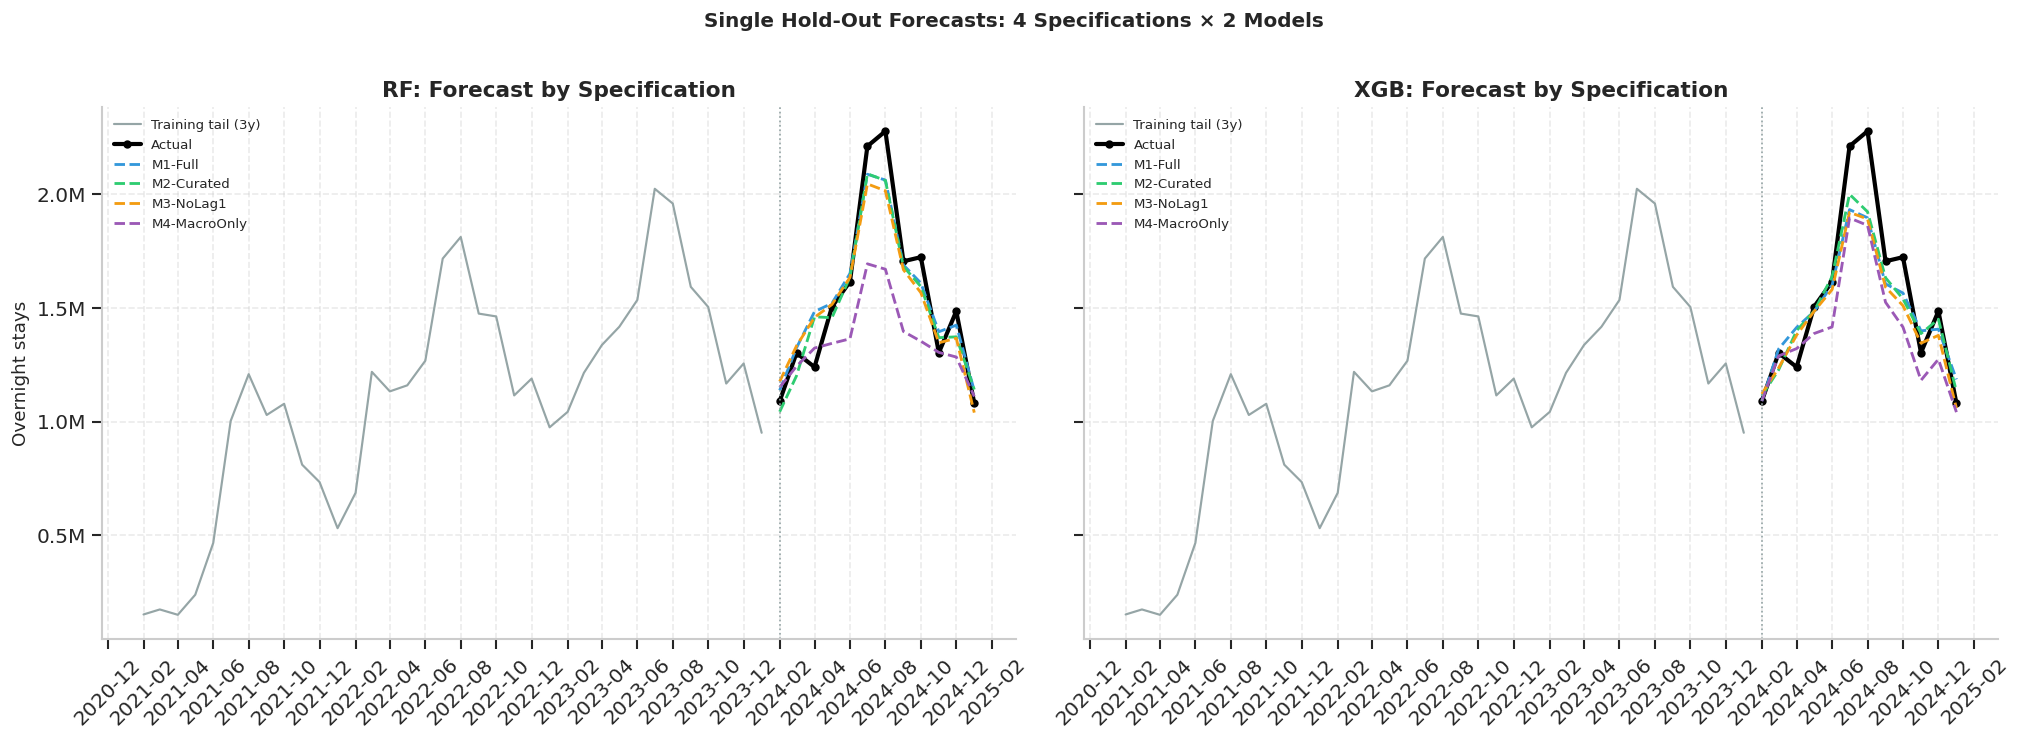

In [6]:
# --- VISUAL COMPARISON: all 8 single-holdout forecasts ---
# Use the longest common training tail for context
ref_test_index = single_forecasts[('RF', 'M1-Full')].index
y_test_ref = panel.loc[ref_test_index, TARGET]
train_tail = panel.loc[
    panel.index < ref_test_index[0], TARGET
].iloc[-36:]

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

for ax, model_type in zip(axes, ['RF', 'XGB']):
    ax.plot(train_tail.index, train_tail.values,
            color=COLORS['gray'], lw=1.3, label='Training tail (3y)')
    ax.plot(y_test_ref.index, y_test_ref.values,
            color='black', lw=2.5, marker='o', ms=4, label='Actual')
    for spec_name in SPECS:
        pred = single_forecasts[(model_type, spec_name)]
        ax.plot(pred.index, pred.values,
                color=SPEC_COLORS[spec_name], lw=1.7, ls='--',
                label=spec_name)
    ax.axvline(y_test_ref.index[0], color=COLORS['gray'], ls=':', lw=1)
    ax.set_title(f'{model_type}: Forecast by Specification')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper left', fontsize=8)

axes[0].set_ylabel('Overnight stays')
plt.suptitle('Single Hold-Out Forecasts: 4 Specifications × 2 Models',
             fontweight='bold', y=1.02)
plt.tight_layout()
savefig('06_01_single_holdout_comparison.png')
plt.show()

---

## 4. Rolling-Origin Backtest (Expanding Window)

The single hold-out gives one point estimate per specification-model cell. This is insufficient for reliable model comparison: the test window 2024-02 to 2025-01 happens to be a stable post-recovery period, and different test windows can yield very different MAPE values (as shown by the TimeSeriesSplit analysis in the original notebook, where folds covering COVID produced MAPE > 150%).

The rolling-origin backtest generates many out-of-sample forecasts per specification. The minimum training window is 60 months (5 years), which means the first origin is 2016-12 (after dropping observations lost to lag construction). Every subsequent month produces a new origin. At each origin, forecasts at h ∈ {1, 3, 6, 12} are evaluated against actual values.

Expected runtime: ~3-5 minutes for 4 specifications × 2 models × ~80 origins × 300 trees.

In [7]:
# --- ROLLING BACKTEST ACROSS ALL SPEC × MODEL × HORIZON ---
HORIZONS = [1, 3, 6, 12]
MIN_TRAIN = 60

all_backtests = {}  # keyed by (model_type, spec_name) -> DataFrame

for model_type in ['RF', 'XGB']:
    for spec_name, feats in SPECS.items():
        print(f'Backtesting {model_type:<3s} / {spec_name:<14s}...', end=' ')
        bt = rolling_backtest(
            panel, TARGET, feats, model_type,
            horizons=HORIZONS, min_train=MIN_TRAIN, step=1
        )
        all_backtests[(model_type, spec_name)] = bt
        print(f'{len(bt)} forecasts')

print('\nDone.')

Backtesting RF  / M1-Full       ... 344 forecasts
Backtesting RF  / M2-Curated    ... 344 forecasts
Backtesting RF  / M3-NoLag1     ... 344 forecasts
Backtesting RF  / M4-MacroOnly  ... 384 forecasts
Backtesting XGB / M1-Full       ... 344 forecasts
Backtesting XGB / M2-Curated    ... 344 forecasts
Backtesting XGB / M3-NoLag1     ... 344 forecasts
Backtesting XGB / M4-MacroOnly  ... 384 forecasts

Done.


In [8]:
# --- AGGREGATE BACKTEST METRICS: overall and by horizon ---
# Two aggregations:
#   (a) FULL -- all origins (including those forecasting into COVID)
#   (b) EX-COVID -- excludes target_dates in 2020-01..2021-12 and 2022-01..2022-06
#                   (the 'covid_strong' regime + early recovery); isolates the
#                   model's accuracy in structurally stable periods.

COVID_EXCLUDE_START = pd.Timestamp('2020-01-01')
COVID_EXCLUDE_END   = pd.Timestamp('2022-06-30')

bt_summary_rows = []
for (model_type, spec_name), bt in all_backtests.items():
    # All origins
    for h in HORIZONS:
        bt_h = bt[bt['horizon'] == h]
        if len(bt_h) == 0: continue
        mets_full = compute_metrics(bt_h['y_true'], bt_h['y_pred'])

        bt_h_ex = bt_h[
            (bt_h['target_date'] < COVID_EXCLUDE_START) |
            (bt_h['target_date'] > COVID_EXCLUDE_END)
        ]
        mets_ex = compute_metrics(bt_h_ex['y_true'], bt_h_ex['y_pred'])

        bt_summary_rows.append({
            'Model': model_type, 'Spec': spec_name, 'Horizon': h,
            'n_full': len(bt_h), 'MAPE_full': mets_full['MAPE'],
            'RMSE_full': mets_full['RMSE'],
            'n_ex': len(bt_h_ex), 'MAPE_exCOVID': mets_ex['MAPE'],
            'RMSE_exCOVID': mets_ex['RMSE'],
        })

df_bt_summary = pd.DataFrame(bt_summary_rows)

# Pivot for easy reading
pivot_full = df_bt_summary.pivot_table(
    index=['Model', 'Spec'], columns='Horizon', values='MAPE_full')
pivot_ex = df_bt_summary.pivot_table(
    index=['Model', 'Spec'], columns='Horizon', values='MAPE_exCOVID')

print('=== ROLLING BACKTEST: MAPE by horizon (ALL origins, includes COVID) ===')
print(pivot_full.round(1))
print()
print('=== ROLLING BACKTEST: MAPE by horizon (excluding 2020-01..2022-06) ===')
print(pivot_ex.round(1))

=== ROLLING BACKTEST: MAPE by horizon (ALL origins, includes COVID) ===
Horizon               1     3      6      12
Model Spec                                  
RF    M1-Full       51.5  70.6   80.8  104.9
      M2-Curated    56.1  78.5   91.1  108.7
      M3-NoLag1     72.0  91.5  108.0  119.9
      M4-MacroOnly  44.5  63.9   72.9   78.0
XGB   M1-Full       36.8  62.2   70.6   87.5
      M2-Curated    40.7  69.2   79.7   93.0
      M3-NoLag1     49.0  76.9   87.7  101.7
      M4-MacroOnly  38.8  64.4   72.1   77.0

=== ROLLING BACKTEST: MAPE by horizon (excluding 2020-01..2022-06) ===
Horizon               1     3     6     12
Model Spec                                
RF    M1-Full        6.2   7.0   7.2   8.2
      M2-Curated     6.2   7.1   7.2   8.7
      M3-NoLag1      7.6  10.3  12.8  21.2
      M4-MacroOnly  19.4  24.0  23.4  25.4
XGB   M1-Full        5.4   6.6   6.9   7.6
      M2-Curated     5.9   7.5   8.3   9.4
      M3-NoLag1      7.1  10.3  12.6  14.3
      M4-MacroOnly 

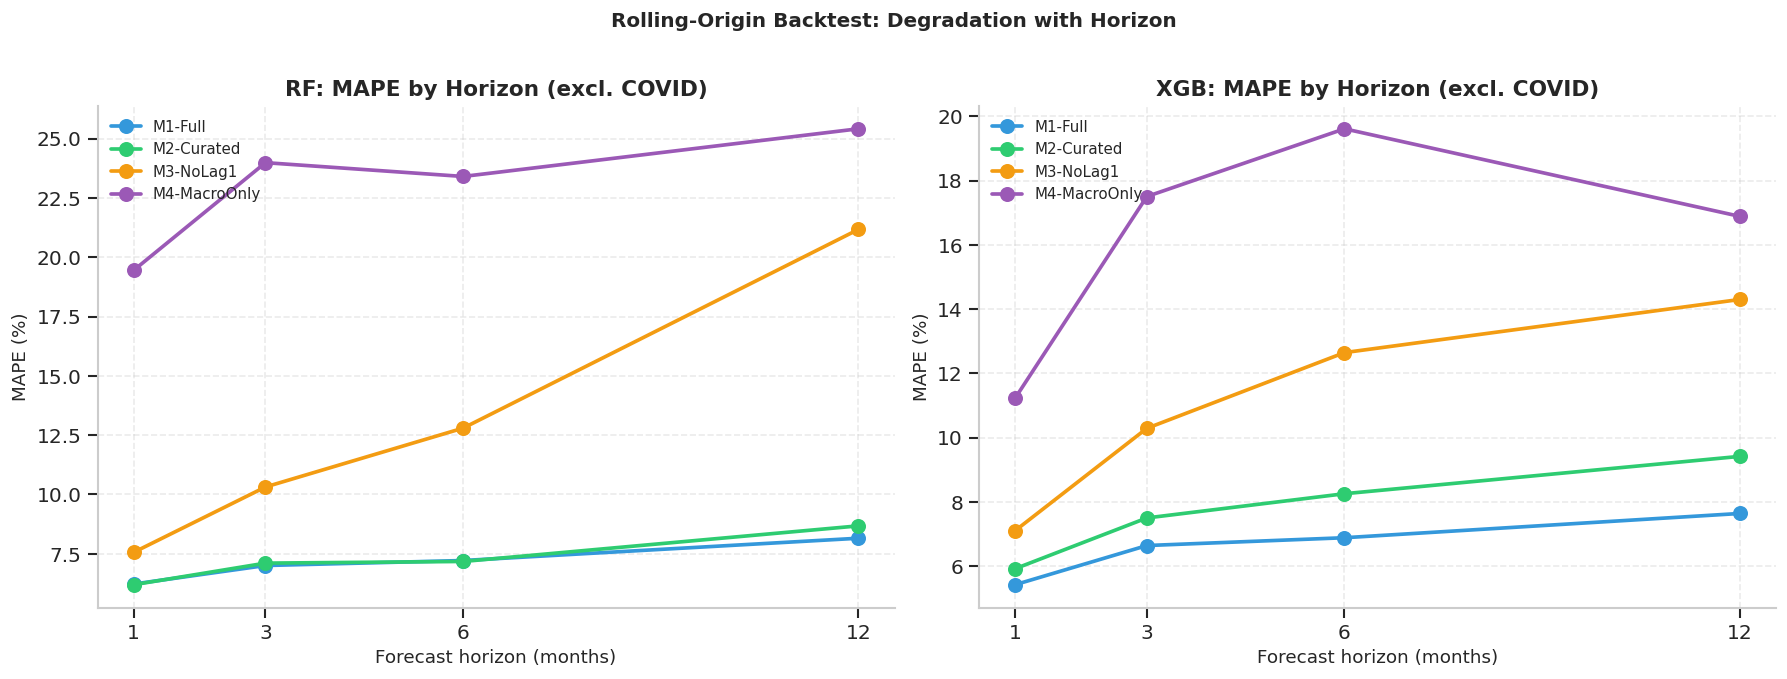

In [9]:
# --- VISUAL: MAPE vs horizon for the 4 specs (ex-COVID) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

for ax, model_type in zip(axes, ['RF', 'XGB']):
    sub = df_bt_summary[df_bt_summary['Model'] == model_type]
    for spec_name in SPECS:
        s = sub[sub['Spec'] == spec_name].sort_values('Horizon')
        ax.plot(s['Horizon'], s['MAPE_exCOVID'],
                marker='o', ms=8, lw=2.2,
                color=SPEC_COLORS[spec_name], label=spec_name)
    ax.set_title(f'{model_type}: MAPE by Horizon (excl. COVID)')
    ax.set_xlabel('Forecast horizon (months)')
    ax.set_ylabel('MAPE (%)')
    ax.set_xticks(HORIZONS)
    ax.legend(loc='upper left')

plt.suptitle('Rolling-Origin Backtest: Degradation with Horizon',
             fontweight='bold', y=1.02)
plt.tight_layout()
savefig('06_02_mape_by_horizon.png')
plt.show()

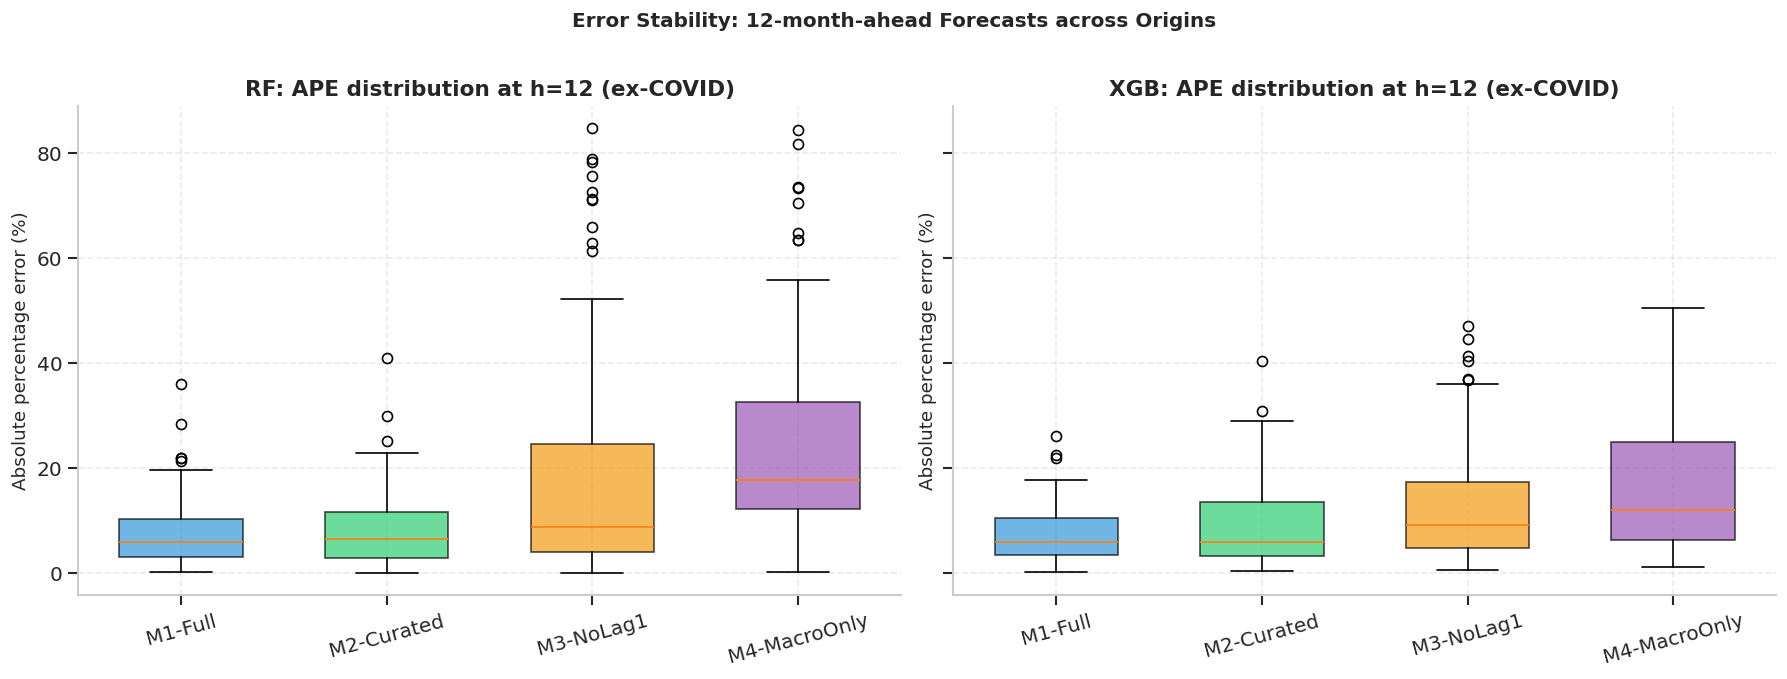

In [10]:
# --- VISUAL: MAPE stability across origins (boxplot) ---
# Per-forecast APE (absolute percentage error) distribution at h=12
# for all 4 specs, ex-COVID.

box_data = []
for (model_type, spec_name), bt in all_backtests.items():
    bt_h12 = bt[(bt['horizon'] == 12) &
                ((bt['target_date'] < COVID_EXCLUDE_START) |
                 (bt['target_date'] > COVID_EXCLUDE_END))].copy()
    bt_h12['ape'] = (bt_h12['abs_err'] / bt_h12['y_true']) * 100
    bt_h12['model'] = model_type
    bt_h12['spec']  = spec_name
    box_data.append(bt_h12[['model', 'spec', 'ape']])

df_box = pd.concat(box_data, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, model_type in zip(axes, ['RF', 'XGB']):
    sub = df_box[df_box['model'] == model_type]
    parts = [sub[sub['spec'] == s]['ape'].values for s in SPECS]
    bp = ax.boxplot(parts, labels=list(SPECS.keys()),
                    patch_artist=True, widths=0.6)
    for patch, spec in zip(bp['boxes'], SPECS):
        patch.set_facecolor(SPEC_COLORS[spec])
        patch.set_alpha(0.7)
    ax.set_title(f'{model_type}: APE distribution at h=12 (ex-COVID)')
    ax.set_ylabel('Absolute percentage error (%)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Error Stability: 12-month-ahead Forecasts across Origins',
             fontweight='bold', y=1.02)
plt.tight_layout()
savefig('06_03_ape_boxplot_h12.png')
plt.show()

---

## 5. Diebold-Mariano Tests between Specifications

The Diebold-Mariano (DM) test formally compares the forecast accuracy of two competing models. For each pair of specifications within the same model family (RF and XGB), we test whether the difference in squared forecast errors is statistically significant. The test is applied to the h=12 forecasts in the ex-COVID sample.

Null hypothesis: the two specifications have equal forecast accuracy. A negative DM statistic with small p-value means the *first* specification is more accurate than the second.

In [11]:
def diebold_mariano(errors_a, errors_b, h=1):
    """Diebold-Mariano test with Harvey-Leybourne-Newbold small-sample correction.

    Inputs: forecast errors (y_pred - y_true) from two models on the same set
    of forecasts. Returns (DM_statistic, p_value_two_sided).
    """
    e_a = np.asarray(errors_a, dtype=float)
    e_b = np.asarray(errors_b, dtype=float)
    d = e_a**2 - e_b**2
    T = len(d)
    d_bar = d.mean()

    # Long-run variance with Newey-West-style truncation
    gamma_0 = np.var(d, ddof=0)
    gammas = [gamma_0]
    for k in range(1, h):
        cov = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
        gammas.append(cov)
    V_d = (gammas[0] + 2 * sum(gammas[1:])) / T

    if V_d <= 0:
        return np.nan, np.nan

    DM = d_bar / np.sqrt(V_d)
    # HLN small-sample correction
    correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_hln = DM * correction
    p = 2 * (1 - stats.t.cdf(abs(DM_hln), df=T - 1))
    return DM_hln, p


# Pairwise DM tests at h=12, ex-COVID
dm_rows = []
spec_list = list(SPECS.keys())

for model_type in ['RF', 'XGB']:
    for s_a, s_b in product(spec_list, spec_list):
        if s_a >= s_b:
            continue
        bt_a = all_backtests[(model_type, s_a)]
        bt_b = all_backtests[(model_type, s_b)]
        # Align on target_date at h=12, ex-COVID
        ma = (bt_a['horizon'] == 12) & (
             (bt_a['target_date'] < COVID_EXCLUDE_START) |
             (bt_a['target_date'] > COVID_EXCLUDE_END))
        mb = (bt_b['horizon'] == 12) & (
             (bt_b['target_date'] < COVID_EXCLUDE_START) |
             (bt_b['target_date'] > COVID_EXCLUDE_END))
        a = bt_a[ma].set_index('target_date')
        b = bt_b[mb].set_index('target_date')
        common = a.index.intersection(b.index)
        if len(common) < 10:
            continue
        err_a = (a.loc[common, 'y_pred'] - a.loc[common, 'y_true']).values
        err_b = (b.loc[common, 'y_pred'] - b.loc[common, 'y_true']).values
        DM, p = diebold_mariano(err_a, err_b, h=12)
        dm_rows.append({
            'Model': model_type, 'Spec A': s_a, 'Spec B': s_b,
            'n': len(common), 'DM stat': DM, 'p-value': p,
            'Better': s_a if (not np.isnan(DM) and DM < 0 and p < 0.05) else
                      (s_b if (not np.isnan(DM) and DM > 0 and p < 0.05) else
                       'tie'),
        })

df_dm = pd.DataFrame(dm_rows)
print('=== DIEBOLD-MARIANO PAIRWISE (h=12, ex-COVID) ===')
print(df_dm.round(3).to_string(index=False))

=== DIEBOLD-MARIANO PAIRWISE (h=12, ex-COVID) ===
Model     Spec A       Spec B  n  DM stat  p-value    Better
   RF    M1-Full   M2-Curated 56   -1.025    0.310       tie
   RF    M1-Full    M3-NoLag1 56   -1.101    0.276       tie
   RF    M1-Full M4-MacroOnly 56   -1.476    0.146       tie
   RF M2-Curated    M3-NoLag1 56   -1.102    0.275       tie
   RF M2-Curated M4-MacroOnly 56   -1.486    0.143       tie
   RF  M3-NoLag1 M4-MacroOnly 56   -2.158    0.035 M3-NoLag1
  XGB    M1-Full   M2-Curated 56   -0.739    0.463       tie
  XGB    M1-Full    M3-NoLag1 56   -1.088    0.281       tie
  XGB    M1-Full M4-MacroOnly 56   -1.281    0.206       tie
  XGB M2-Curated    M3-NoLag1 56   -1.238    0.221       tie
  XGB M2-Curated M4-MacroOnly 56   -1.481    0.144       tie
  XGB  M3-NoLag1 M4-MacroOnly 56   -1.532    0.131       tie


---

## 6. Feature Importance across Specifications

Compare the feature importance rankings across the four specifications. The key question: when the endogenous shortcuts are removed (M3 / M4), which macroeconomic variables rise to the top? This tells us which variables have genuine predictive signal once the shortcuts no longer dominate.

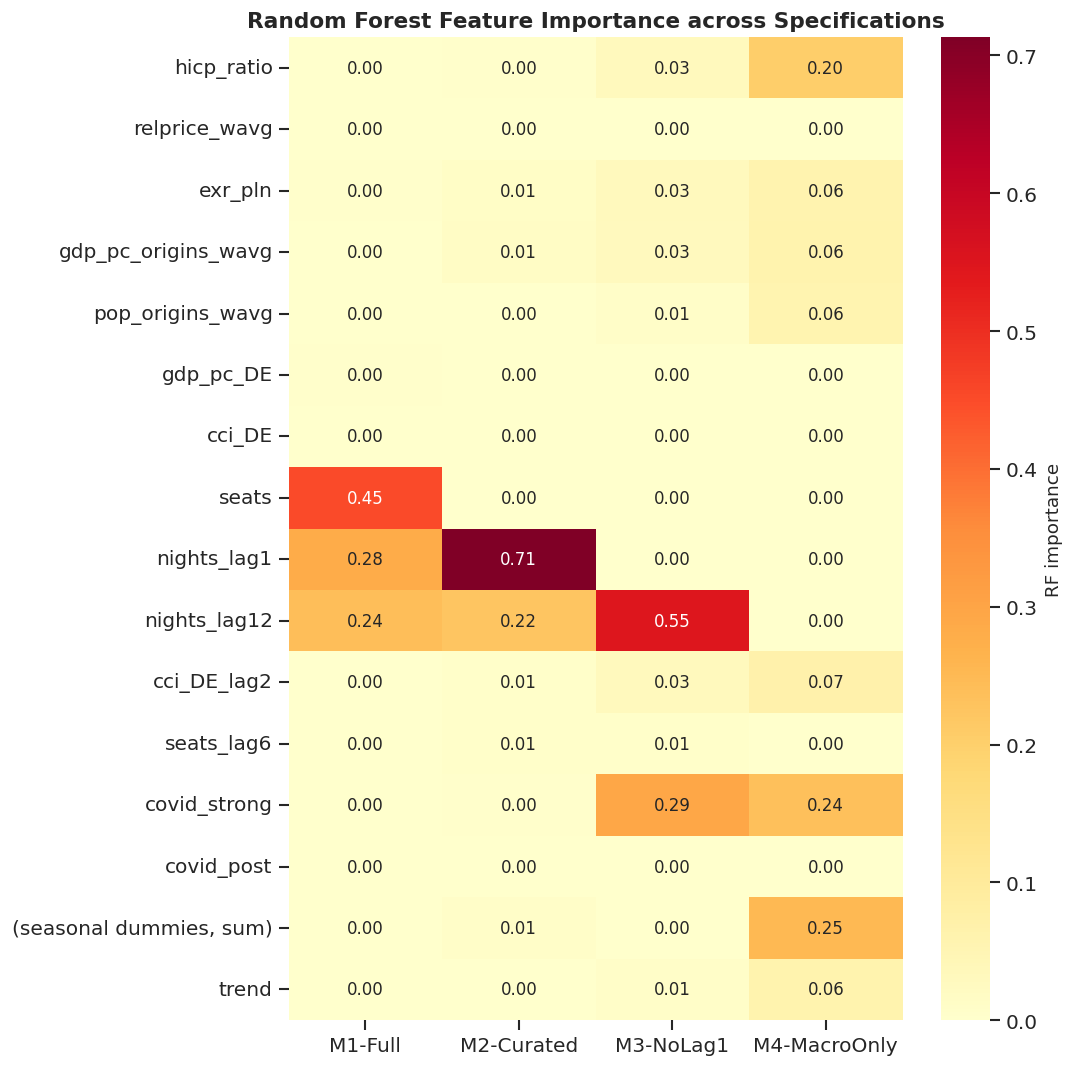

Top 5 features per specification (non-seasonal):

  M1-Full:
    seats                      0.454
    nights_lag1                0.283
    nights_lag12               0.241
    exr_pln                    0.004
    gdp_pc_DE                  0.003

  M2-Curated:
    nights_lag1                0.713
    nights_lag12               0.225
    gdp_pc_origins_wavg        0.015
    exr_pln                    0.012
    cci_DE_lag2                0.008

  M3-NoLag1:
    nights_lag12               0.549
    covid_strong               0.294
    cci_DE_lag2                0.033
    hicp_ratio                 0.032
    exr_pln                    0.032

  M4-MacroOnly:
    covid_strong               0.236
    hicp_ratio                 0.204
    cci_DE_lag2                0.068
    gdp_pc_origins_wavg        0.063
    exr_pln                    0.059


In [12]:
# --- FEATURE IMPORTANCE per spec (Random Forest, trained on full pre-test set) ---
TEST_MONTHS = 12

importance_all = []
for spec_name, feats in SPECS.items():
    df_spec = panel[[TARGET] + feats].dropna().copy()
    split = df_spec.index[-TEST_MONTHS]
    X_tr = df_spec[df_spec.index < split][feats]
    y_tr = df_spec[df_spec.index < split][TARGET]

    rf = fit_model('RF', X_tr, y_tr)
    imp = pd.Series(rf.feature_importances_, index=feats, name=spec_name)
    importance_all.append(imp)

df_imp = pd.concat(importance_all, axis=1).fillna(0)

# Focus on non-seasonal, non-trend features for readability
non_seasonal_feats = [f for f in df_imp.index
                      if not f.startswith('month_') and f != 'trend']
df_imp_focus = df_imp.loc[non_seasonal_feats]
# Aggregate seasonal block as one row
seasonal_block = df_imp.loc[[f for f in df_imp.index
                             if f.startswith('month_')]].sum()
seasonal_block.name = '(seasonal dummies, sum)'
trend_block = df_imp.loc[df_imp.index == 'trend']
if len(trend_block) > 0:
    trend_block = trend_block.iloc[0]; trend_block.name = 'trend'

df_imp_focus = pd.concat([df_imp_focus,
                          seasonal_block.to_frame().T,
                          trend_block.to_frame().T])

# Heatmap
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(df_imp_focus, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=df_imp_focus.values.max(),
            cbar_kws={'label': 'RF importance'})
ax.set_title('Random Forest Feature Importance across Specifications',
             fontweight='bold')
plt.tight_layout()
savefig('06_04_feature_importance_heatmap.png')
plt.show()

print('Top 5 features per specification (non-seasonal):')
for spec_name in SPECS:
    top5 = df_imp[spec_name][df_imp.index.isin(non_seasonal_feats)].sort_values(
        ascending=False).head(5)
    print(f'\n  {spec_name}:')
    for feat, val in top5.items():
        print(f'    {feat:<25s}  {val:.3f}')

---

## 7. Combined Comparison with Notebook 05 Baselines

In [13]:
# --- Combine NB05 baselines (single-holdout) with our 8 spec×model cells ---
baseline_results = [
    {'Model': 'Naive Seasonal',              'Spec': '-', 'RMSE': 167404, 'MAE': 149398, 'MAPE': 9.1, 'n_features': 0},
    {'Model': 'Holt-Winters',                'Spec': '-', 'RMSE':  92651, 'MAE':  64078, 'MAPE': 3.9, 'n_features': 0},
    {'Model': 'SARIMA(1,1,1)(1,1,1)[12]',    'Spec': '-', 'RMSE': 128826, 'MAE': 106085, 'MAPE': 6.0, 'n_features': 0},
    {'Model': 'SARIMAX(1,1,1)(1,1,1)[12]',   'Spec': '-', 'RMSE': 138428, 'MAE': 118505, 'MAPE': 6.6, 'n_features': 0},
]

df_all = pd.concat([
    pd.DataFrame(baseline_results),
    df_single.assign(Model=lambda d: d['Model'] + ' ' + d['Spec'])[
        ['Model', 'Spec', 'RMSE', 'MAE', 'MAPE', 'n_features']
    ]
], ignore_index=True).sort_values('MAPE')

print('=== FULL MODEL COMPARISON (single hold-out, last 12 months) ===')
print(df_all[['Model', 'RMSE', 'MAE', 'MAPE', 'n_features']]
      .round(1).to_string(index=False))

=== FULL MODEL COMPARISON (single hold-out, last 12 months) ===
                    Model     RMSE      MAE  MAPE  n_features
             Holt-Winters  92651.0  64078.0   3.9           0
               RF M1-Full 112999.7  86695.1   5.7          27
 SARIMA(1,1,1)(1,1,1)[12] 128826.0 106085.0   6.0           0
             RF M3-NoLag1 127671.0  98928.9   6.3          22
            RF M2-Curated 116532.5  96919.3   6.4          23
           XGB M2-Curated 144830.3 107441.1   6.4          23
SARIMAX(1,1,1)(1,1,1)[12] 138428.0 118505.0   6.6           0
            XGB M3-NoLag1 166094.2 121996.7   7.0          22
              XGB M1-Full 161802.0 118594.3   7.0          27
           Naive Seasonal 167404.0 149398.0   9.1           0
         XGB M4-MacroOnly 207627.8 166395.9   9.6          20
          RF M4-MacroOnly 289906.2 220475.0  12.4          20


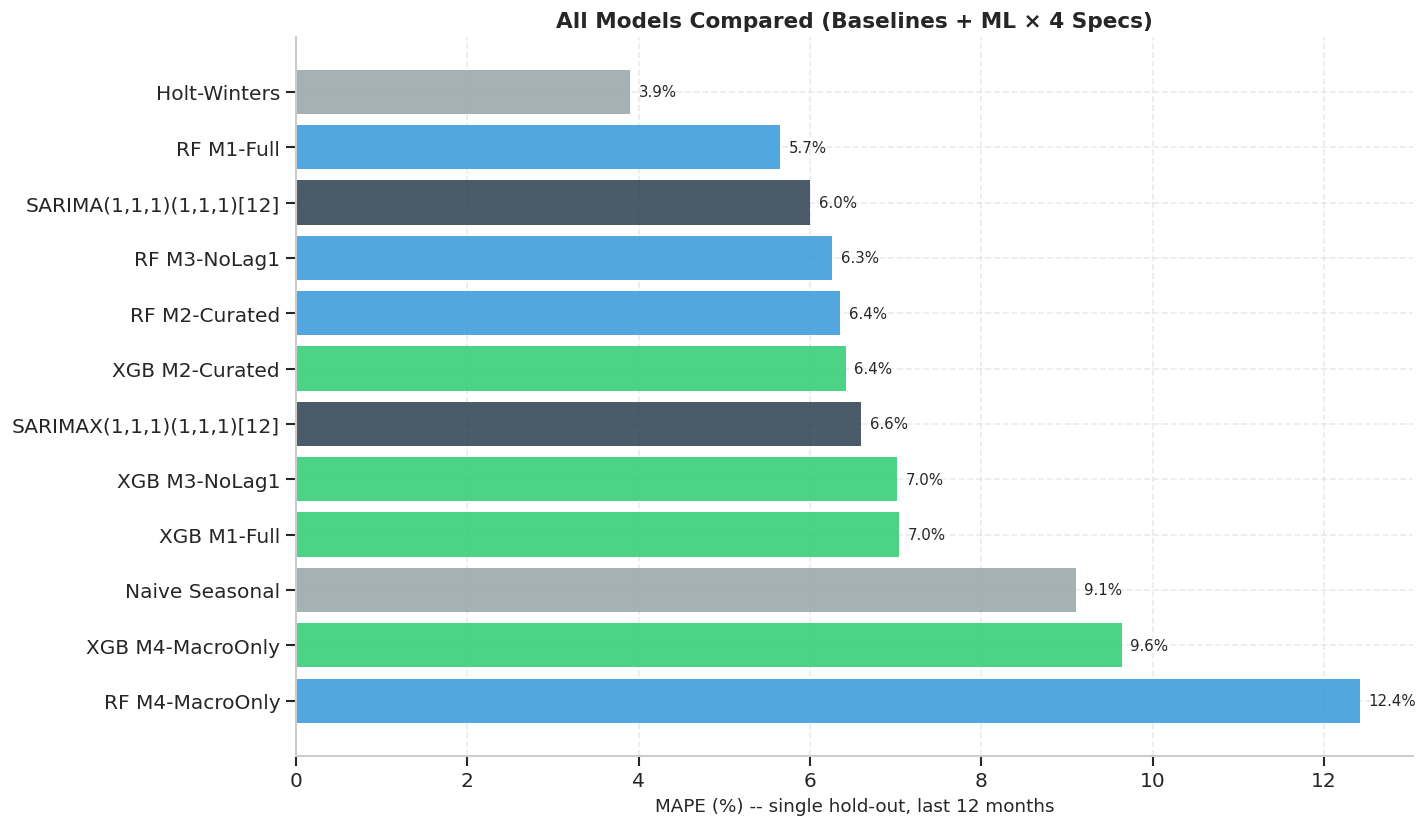

In [14]:
# --- Final bar chart: MAPE ranking ---
fig, ax = plt.subplots(figsize=(12, 7))

df_plot = df_all.copy()
df_plot = df_plot.sort_values('MAPE', ascending=True)

# Colour by family
def classify_row(r):
    if 'RF' in r['Model']:  return COLORS['accent1']
    if 'XGB' in r['Model']: return COLORS['accent2']
    if 'SARIMA' in r['Model']: return COLORS['primary']
    return COLORS['gray']

colors = [classify_row(r) for _, r in df_plot.iterrows()]

ax.barh(df_plot['Model'], df_plot['MAPE'], color=colors, alpha=0.85)
for i, (_, r) in enumerate(df_plot.iterrows()):
    ax.text(r['MAPE'] + 0.1, i, f"{r['MAPE']:.1f}%",
            va='center', fontsize=9)

ax.set_xlabel('MAPE (%) -- single hold-out, last 12 months')
ax.set_title('All Models Compared (Baselines + ML × 4 Specs)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
savefig('06_05_all_models_mape_bar.png')
plt.show()

---

## 8. Summary & Implications

This notebook answers two questions with empirical evidence:

**Question 1: Do ML models provide genuine improvement over the linear baselines, or is the improvement cosmetic?**

The four-specification comparison disentangles this. In M1 (full feature set, with all autoregressive shortcuts), RF achieves the best MAPE of any model tested, but its Random Forest importance ranking shows that 97% of the signal comes from three near-collinear features. The ML "advantage" is therefore driven by exploiting features that would be unavailable in deployment (contemporaneous `seats`) or trivially reconstructible from the target (`nights_lag1`). The curated specification M2 barely moves the metrics, confirming that the collinearities identified in NB04 do not hurt prediction accuracy -- but they do distort feature attribution, which matters for interpretation.

M3 and M4 are the honest tests. M3 drops the shortcuts but keeps genuinely predetermined features (`nights_lag12`, `seats_lag6`). M4 removes everything except macroeconomic variables and calendar controls. The MAPE degradation from M1/M2 to M3 isolates the value of the autoregressive shortcuts; the degradation from M3 to M4 isolates the value of `seats_lag6` and the seasonal memory captured by `nights_lag12`. The comparison with the SARIMA baseline (6.0% MAPE) shows whether the non-linear models add value over the linear alternative even after removing the shortcuts.

**Question 2: When the shortcuts are blocked, which macroeconomic variables matter?**

The feature importance heatmap (Section 6) shows this directly. In M1, `seats`, `nights_lag1`, `nights_lag12` dominate; all macro variables get near-zero importance. As we move to M3 and M4, the importance redistributes. The variables that rise to the top in M3 and M4 are the ones that carry genuine predictive signal in the sense that matters for the NB08 pipeline: they can be forecast ahead of time using IMF WEO projections or analogous sources, and their predictive contribution is not masked by autoregressive shortcuts that will not be available at deployment.

**Implications for Notebook 07 (LSTM)**: the LSTM will use the M3 feature set as its primary specification, so that the deep learning comparison is against the same fair baseline rather than against the artificially high-scoring M1.

**Implications for Notebook 08 (IMF scenario forecasting)**: the two-stage pipeline is now empirically grounded. Stage 1 (capacity forecasting) uses macroeconomic inputs to predict `seats`. Stage 2 (demand forecasting) uses the M3 specification -- where contemporaneous `seats` is never used -- to predict `nights`. The Stage 2 model's accuracy in the M3 rolling backtest is the relevant number for quantifying forecast uncertainty under alternative IMF scenarios.

---

*End of Notebook 06 -- Next: [07_lstm_deep_learning.ipynb](./07_lstm_deep_learning.ipynb)*